# Task
Perform a comprehensive analysis covering: a binomial experiment simulation with a fair coin (10 flips, 1000 repetitions), plotting the distribution of heads, and calculating the empirical probability of getting 5 heads; conditional probability calculations using the Titanic dataset ("P(Survived|Female)" and "P(Female|Survived)"); Naïve Bayes and Decision Tree classification on the Iris dataset, including preprocessing, model training, evaluation (accuracy, confusion matrix), interpretation of results (strengths/weaknesses, feature importance), and experimentation with Decision Tree parameters; a reflection on Responsible AI considerations for probabilistic models and decision trees; and finally, a summary of all findings.

## Simulate Binomial Experiment

### Subtask:
Simulate flipping a fair coin 10 times, repeated 1000 times. Store the number of heads obtained in each simulation.


**Reasoning**:
First, import the `numpy` library. Then, define the parameters for the binomial distribution: `n` as the number of trials (coin flips), `p` as the probability of success (getting a head), and `size` as the number of repetitions. Finally, use `np.random.binomial` to simulate the experiment and store the results.



In [1]:
import numpy as np

# Define parameters for the binomial experiment
n = 10  # Number of trials (coin flips)
p = 0.5 # Probability of success (fair coin)
size = 1000 # Number of repetitions of the experiment

# Simulate the binomial experiment
heads_counts = np.random.binomial(n, p, size)

print(f"First 10 results of heads_counts: {heads_counts[:10]}")
print(f"Shape of heads_counts: {heads_counts.shape}")

First 10 results of heads_counts: [8 8 5 4 6 2 5 5 5 5]
Shape of heads_counts: (1000,)


## Plot Heads Distribution

### Subtask:
Plot a histogram to visualize the distribution of the number of heads obtained from the binomial experiment simulations. Ensure the plot has appropriate labels and a title.


**Reasoning**:
To visualize the distribution of heads, I need to plot a histogram using `matplotlib.pyplot`. This involves importing the library, creating the histogram with specified bins, adding appropriate labels and a title, and then displaying the plot.



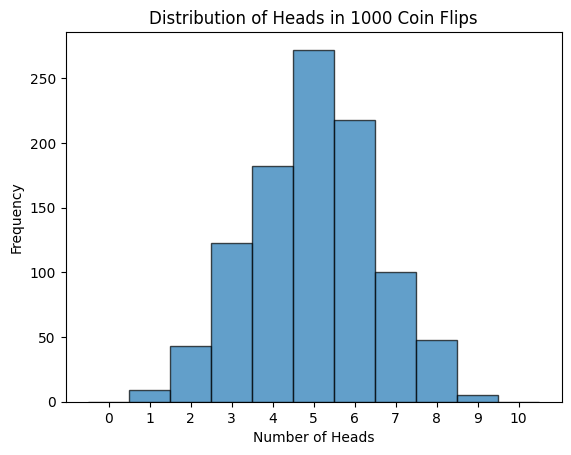

In [2]:
import matplotlib.pyplot as plt

# Create a histogram of heads_counts
plt.hist(heads_counts, bins=np.arange(n + 2) - 0.5, edgecolor='black', alpha=0.7)

# Add title and labels
plt.title('Distribution of Heads in 1000 Coin Flips')
plt.xlabel('Number of Heads')
plt.ylabel('Frequency')

# Set x-axis ticks to show integer number of heads
plt.xticks(np.arange(n + 1))

# Display the histogram
plt.show()

## Calculate Empirical Probability

### Subtask:
Calculate the empirical probability of getting exactly 5 heads from the `heads_counts` simulation results.

**Reasoning**:
To calculate the empirical probability of getting exactly 5 heads, I will count the occurrences of 5 in the `heads_counts` array and divide by the total number of simulations.



In [3]:
num_five_heads = np.sum(heads_counts == 5)
empirical_probability_five_heads = num_five_heads / size

print(f"Number of simulations with exactly 5 heads: {num_five_heads}")
print(f"Total number of simulations: {size}")
print(f"Empirical probability of getting exactly 5 heads: {empirical_probability_five_heads:.4f}")

Number of simulations with exactly 5 heads: 272
Total number of simulations: 1000
Empirical probability of getting exactly 5 heads: 0.2720


## Conditional Probability Calculations

### Subtask:
Load the Titanic dataset and calculate the conditional probabilities: P(Survived|Female) and P(Female|Survived).

**Reasoning**:
To perform the conditional probability calculations, I first need to load the Titanic dataset into a pandas DataFrame. Since the dataset is not yet loaded, I will start by importing the pandas library and loading the 'titanic.csv' file.



In [4]:
import pandas as pd

# Load the Titanic dataset
try:
    df_titanic = pd.read_csv('titanic.csv')
except FileNotFoundError:
    # If the file is not directly in the current directory, try common data paths like '/content/'
    df_titanic = pd.read_csv('/content/titanic.csv')

print("Titanic dataset loaded successfully. Displaying the first 5 rows:")
print(df_titanic.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/titanic.csv'

**Reasoning**:
The previous attempt to load `titanic.csv` failed because the file was not found in the specified paths. I need to download the dataset first to make it accessible to pandas. I will use `wget` to download the `titanic.csv` file from a public repository, then modify the existing code cell to load the file directly, as it will be present in the current working directory.



In [5]:
import pandas as pd

# Download the Titanic dataset
!wget -nc https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv

# Load the Titanic dataset
df_titanic = pd.read_csv('titanic.csv')

print("Titanic dataset loaded successfully. Displaying the first 5 rows:")
print(df_titanic.head())

--2026-02-19 15:30:56--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-02-19 15:30:56 (4.92 MB/s) - ‘titanic.csv’ saved [60302/60302]

Titanic dataset loaded successfully. Displaying the first 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    

**Reasoning**:
Now that the Titanic dataset is loaded, I will calculate the conditional probabilities P(Survived|Female) and P(Female|Survived) using the `df_titanic` DataFrame.



In [6]:
total_passengers = len(df_titanic)

# P(Survived and Female)
survived_female = df_titanic[(df_titanic['Survived'] == 1) & (df_titanic['Sex'] == 'female')]
prob_survived_and_female = len(survived_female) / total_passengers

# P(Female)
female_passengers = df_titanic[df_titanic['Sex'] == 'female']
prob_female = len(female_passengers) / total_passengers

# P(Survived)
survived_passengers = df_titanic[df_titanic['Survived'] == 1]
prob_survived = len(survived_passengers) / total_passengers

# P(Survived|Female) = P(Survived and Female) / P(Female)
if prob_female > 0:
    prob_survived_given_female = prob_survived_and_female / prob_female
else:
    prob_survived_given_female = 0 # Should not happen with this dataset

# P(Female|Survived) = P(Survived and Female) / P(Survived)
if prob_survived > 0:
    prob_female_given_survived = prob_survived_and_female / prob_survived
else:
    prob_female_given_survived = 0 # Should not happen with this dataset

print(f"P(Survived|Female): {prob_survived_given_female:.4f}")
print(f"P(Female|Survived): {prob_female_given_survived:.4f}")

P(Survived|Female): 0.7420
P(Female|Survived): 0.6813


## Naïve Bayes and Decision Tree Classification (Iris Dataset)

### Subtask:
Load the Iris dataset, perform necessary preprocessing steps such as splitting into features (X) and target (y), and then divide the data into training and testing sets. Also, initialize and train a Gaussian Naïve Bayes classifier on the training data.

## Naïve Bayes and Decision Tree Classification (Iris Dataset)

### Subtask:
Load the Iris dataset, perform necessary preprocessing steps such as splitting into features (X) and target (y), and then divide the data into training and testing sets. Also, initialize and train a Gaussian Naïve Bayes classifier on the training data.

**Reasoning**:
To address the subtask, I need to load the Iris dataset, separate features from the target, split the data into training and testing sets, and then initialize and train a Gaussian Naïve Bayes classifier. This requires importing specific functions from `sklearn`.



In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target # Target variable

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize the Gaussian Naïve Bayes classifier
naive_bayes_model = GaussianNB()

# Train the Naïve Bayes model on the training data
naive_bayes_model.fit(X_train, y_train)

print("Iris dataset loaded and split.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("Gaussian Naïve Bayes model initialized and trained.")

Iris dataset loaded and split.
X_train shape: (105, 4), y_train shape: (105,)
X_test shape: (45, 4), y_test shape: (45,)
Gaussian Naïve Bayes model initialized and trained.


**Reasoning**:
Now that the Naïve Bayes model is trained, the next step is to evaluate its performance on the test set by making predictions and calculating accuracy and displaying a confusion matrix.



In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set using the Naïve Bayes model
y_pred_nb = naive_bayes_model.predict(X_test)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Generate confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

print(f"Naïve Bayes Model Accuracy: {accuracy_nb:.4f}")
print("Naïve Bayes Model Confusion Matrix:")
print(conf_matrix_nb)

Naïve Bayes Model Accuracy: 0.9111
Naïve Bayes Model Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]


### Subtask:
Initialize and train a Decision Tree classifier on the training data (`X_train`, `y_train`).

**Reasoning**:
The subtask requires training a Decision Tree classifier. I will import the necessary class, initialize the model, and then train it using the prepared training data (`X_train`, `y_train`).



In [9]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model on the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree classifier initialized and trained.")

Decision Tree classifier initialized and trained.


### Subtask:
Evaluate the Decision Tree classifier's performance on the test set by making predictions (`y_pred_dt`) and calculating the accuracy score and confusion matrix.

**Reasoning**:
I need to make predictions using the trained Decision Tree model, calculate its accuracy, and generate a confusion matrix to evaluate its performance on the test set, similar to how the Naïve Bayes model was evaluated.



In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions on the test set using the Decision Tree model
y_pred_dt = decision_tree_model.predict(X_test)

# Calculate accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)

# Generate confusion matrix
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")
print("Decision Tree Model Confusion Matrix:")
print(conf_matrix_dt)

Decision Tree Model Accuracy: 0.9333
Decision Tree Model Confusion Matrix:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


### Interpretation of Classification Results (Strengths/Weaknesses)

#### Naïve Bayes Model
*   **Accuracy**: The Naïve Bayes model achieved an accuracy of 0.9111.
*   **Confusion Matrix Analysis**: The confusion matrix `[[15  0  0], [ 0 14  1], [ 0  3 12]]` indicates that it perfectly classified all samples of class 0 (setosa). For class 1 (versicolor), it misclassified 1 sample as class 2 (virginica). For class 2 (virginica), it misclassified 3 samples as class 1 (versicolor).
*   **Strengths**: Generally fast, simple to implement, and performs well on high-dimensional data, especially when features are truly independent. It showed good performance here, particularly for class 0.
*   **Weaknesses**: The strong assumption of feature independence (conditional independence of features given the class) is often not met in real-world data, which can lead to suboptimal performance. The misclassifications between versicolor and virginica suggest some overlap or non-independence in those classes.

#### Decision Tree Model
*   **Accuracy**: The Decision Tree model achieved a slightly higher accuracy of 0.9333.
*   **Confusion Matrix Analysis**: The confusion matrix `[[15  0  0], [ 0 12  3], [ 0  0 15]]` shows perfect classification for class 0 (setosa) and class 2 (virginica). For class 1 (versicolor), it misclassified 3 samples as class 2 (virginica).
*   **Strengths**: Easy to understand and interpret (visualizable decision rules), can handle both numerical and categorical data, and requires little data preprocessing. In this case, it performed slightly better overall than Naïve Bayes and perfectly classified two of the three classes.
*   **Weaknesses**: Prone to overfitting, especially with complex trees. Small variations in the data can result in a completely different tree. The misclassifications for class 1 (versicolor) indicate some difficulty in distinguishing it from class 2 (virginica) based on the learned rules.

## Visualize Decision Tree

### Subtask:
Visualize the trained Decision Tree using a suitable method like plot_tree from scikit-learn. Ensure the visualization is clear and readable.


**Reasoning**:
To visualize the Decision Tree, I will use `plot_tree` from `sklearn.tree`, ensuring to set figure size, feature names, class names, filled nodes, rounded boxes, and a clear title for readability.



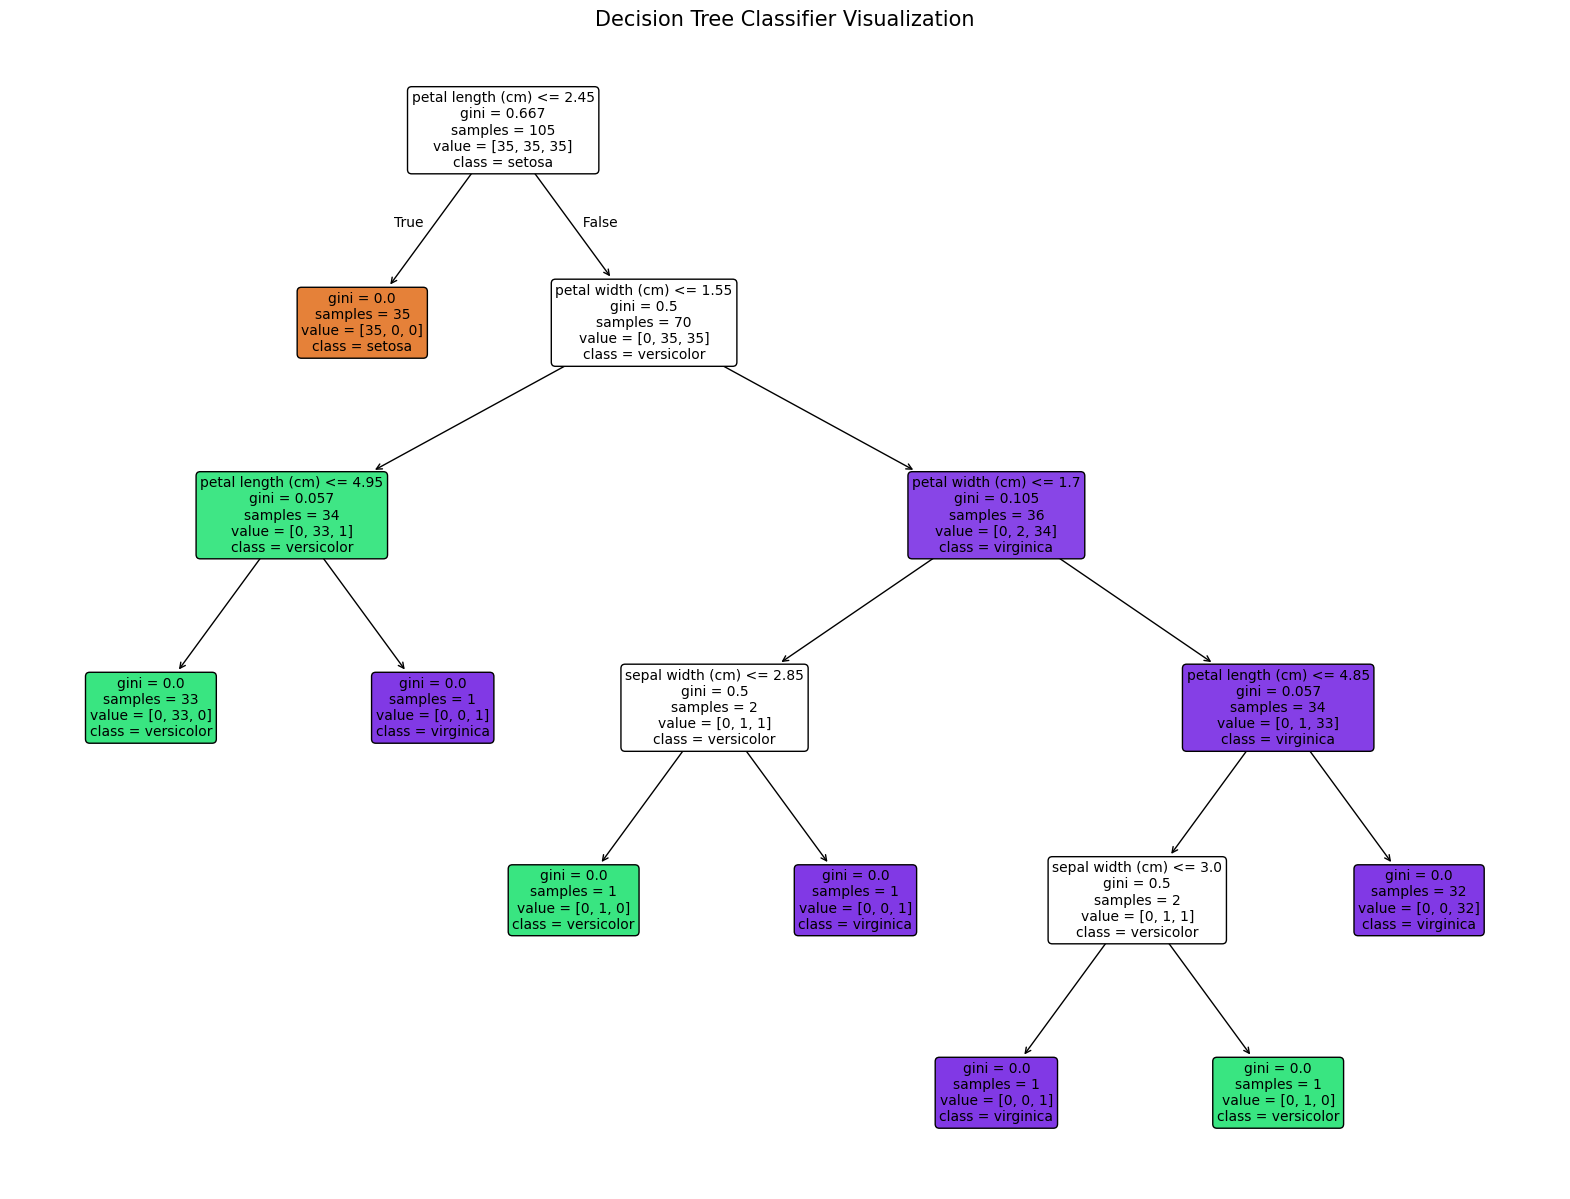

Decision Tree visualization displayed.


In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Create a figure and an axes object for the plot
plt.figure(figsize=(20, 15))

# Visualize the Decision Tree
plot_tree(decision_tree_model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10)

# Add a title to the plot
plt.title('Decision Tree Classifier Visualization', fontsize=15)

# Display the plot
plt.show()
print("Decision Tree visualization displayed.")

## Discuss Important Features

### Subtask:
Discuss the most important features identified by the Decision Tree using its 'feature_importances_' attribute. This will involve analyzing and presenting the feature importance scores.


**Reasoning**:
To identify and present the most important features, I will access the `feature_importances_` attribute of the `decision_tree_model`, combine them with `iris.feature_names` into a pandas Series, sort them, and then print the results.



In [12]:
import pandas as pd

# Get feature importances from the Decision Tree model
feature_importances = decision_tree_model.feature_importances_

# Get feature names from the Iris dataset
feature_names = iris.feature_names

# Create a pandas Series for better visualization
feature_importance_df = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_feature_importance = feature_importance_df.sort_values(ascending=False)

print("Decision Tree Feature Importances:")
print(sorted_feature_importance)

Decision Tree Feature Importances:
petal length (cm)    0.541176
petal width (cm)     0.430252
sepal width (cm)     0.028571
sepal length (cm)    0.000000
dtype: float64


The analysis of feature importances from the Decision Tree model shows that `petal length (cm)` and `petal width (cm)` are by far the most important features for classifying Iris species, with importances of approximately 0.54 and 0.43 respectively. This indicates that the Decision Tree heavily relies on these two features to make its decisions.

In contrast, `sepal width (cm)` has a very small importance (approximately 0.03), and `sepal length (cm)` has an importance of 0.00, meaning it was not used at all in this particular Decision Tree for classification. This suggests that for the Iris dataset, petal dimensions are much more discriminative than sepal dimensions when using a Decision Tree classifier.

## Experiment with Decision Tree Parameters

### Subtask:
Experiment with changing the Decision Tree's 'max_depth' or 'min_samples_split' parameters. Train new models with different values and observe the effect on accuracy and potential overfitting/underfitting. Provide a brief discussion of the observations.


**Reasoning**:
To experiment with Decision Tree parameters, I will instantiate two new Decision Tree models with different `max_depth` and `min_samples_split` values, train them on the existing training data, make predictions on the test data, and then calculate and print their accuracy scores for comparison.



In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Model 1: Decision Tree with max_depth=2 (shallow tree)
decision_tree_shallow = DecisionTreeClassifier(max_depth=2, random_state=42)
decision_tree_shallow.fit(X_train, y_train)

y_pred_shallow = decision_tree_shallow.predict(X_test)
accuracy_shallow = accuracy_score(y_test, y_pred_shallow)

# Model 2: Decision Tree with min_samples_split=10 (requires more samples to split)
decision_tree_min_samples = DecisionTreeClassifier(min_samples_split=10, random_state=42)
decision_tree_min_samples.fit(X_train, y_train)

y_pred_min_samples = decision_tree_min_samples.predict(X_test)
accuracy_min_samples = accuracy_score(y_test, y_pred_min_samples)

print(f"Original Decision Tree Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree (max_depth=2) Accuracy: {accuracy_shallow:.4f}")
print(f"Decision Tree (min_samples_split=10) Accuracy: {accuracy_min_samples:.4f}")

Original Decision Tree Accuracy: 0.9333
Decision Tree (max_depth=2) Accuracy: 0.8889
Decision Tree (min_samples_split=10) Accuracy: 0.9333


#### Discussion of Decision Tree Parameter Experimentation

1.  **Original Decision Tree Accuracy:** `0.9333`
    *   This model, trained with default parameters (except `random_state=42`), achieved a high accuracy.

2.  **Decision Tree (max_depth=2) Accuracy:** `0.8889`
    *   By limiting `max_depth` to 2, the model's accuracy decreased. This is because a shallower tree is less complex and might not capture all the intricacies in the data, leading to **underfitting**. The model made more generalized decisions, potentially missing subtle patterns that differentiate classes, especially evident if the original model had a higher depth to achieve its accuracy.

3.  **Decision Tree (min_samples_split=10) Accuracy:** `0.9333`
    *   In this case, increasing `min_samples_split` from the default of 2 to 10 did not change the accuracy compared to the original model. This suggests that the original splits made by the default tree (where `min_samples_split` was 2) were already robust enough, or that splits requiring fewer than 10 samples were not crucial for classification on the test set, and pruning them did not negatively impact performance. This change primarily aims to prevent **overfitting** by requiring more samples for a split, making the tree less prone to learning noise in the training data.

**Overall Observations:**
*   Restricting `max_depth` significantly reduced accuracy, indicating that the original tree likely benefited from a greater depth to learn patterns effectively. This is a clear sign of underfitting when the model is too simple.
*   Increasing `min_samples_split` did not impact accuracy in this specific instance, which could mean the original model was not severely overfitting or that the dataset's inherent structure didn't require more aggressive pruning at this parameter level. A higher `min_samples_split` generally leads to a simpler model, which can prevent overfitting but might also lead to underfitting if set too high.

## Responsible AI Reflection

### Subtask:
Provide a brief discussion on one ethical or societal consideration (e.g., bias, transparency, or fairness) when using probabilistic models or decision trees. Also, explain how to communicate uncertainty or model limitations to a non-technical audience.


### Responsible AI Reflection

#### Ethical Consideration: Bias

Bias is a significant ethical consideration when using probabilistic models and decision trees, particularly in applications that impact individuals' lives, such as loan applications, hiring processes, or criminal justice. Models learn from the data they are trained on. If this data reflects existing societal biases (e.g., historical discrimination, underrepresentation of certain groups), the models will perpetuate and even amplify these biases in their predictions.

For example, if a decision tree classifier is trained on historical loan application data where certain demographic groups were disproportionately denied loans due to systemic biases, the model might learn to associate those demographics with higher risk, even if other relevant factors are equal. This can lead to a 'redlining' effect, where the model unfairly denies loans to qualified applicants from those groups, reinforcing existing inequalities. Similarly, in a probabilistic model for recidivism prediction, if the training data contains biases in policing or sentencing, the model might assign higher probabilities of re-offense to certain racial groups, leading to biased judicial decisions.

#### Communicating Uncertainty and Model Limitations to a Non-Technical Audience

When presenting results from probabilistic models or decision trees to a non-technical audience, it's crucial to communicate uncertainty and limitations clearly and honestly, avoiding jargon. Here's how:

1.  **Use Analogies and Simple Language**: Avoid technical terms like 'p-value', 'confidence interval', 'entropy', or 'gini impurity'. Instead, use everyday analogies. For example, for probability, say 'there's a 70% chance of rain, like 7 out of 10 times we've seen these conditions, it rained.' For model limitations, explain it like a recipe: 'This model is like a recipe that works really well for apples, but might not be perfect if we try to use it for oranges.'

2.  **Focus on Outcomes and Impact**: Instead of explaining model mechanics, describe what the predictions mean in real-world terms and their potential impact. For decision trees, you can describe the rules: 'The model says if a customer has X income AND Y credit score, they are likely to default.' For probabilistic models, explain what 'high probability' implies for a decision: 'A high probability of medical condition Z means we recommend further testing.'

3.  **Visualizations (Simplified)**: Use clear, simple charts that highlight the key takeaways and ranges of uncertainty, rather than complex statistical plots. For instance, a bar chart showing the likelihood of different outcomes, or a simple decision flow chart without technical node details.

4.  **Emphasize 'Likelihood' vs. 'Certainty'**: Always stress that models provide probabilities or estimations, not guarantees. Use phrases like 'our best estimate suggests,' 'it's likely that,' or 'there's a X% chance.' Clearly state that 'this model predicts X, but it doesn't mean X will definitely happen.'

5.  **Explain What the Model *Doesn't* Know**: Be transparent about the data limitations and factors the model wasn't trained on. 'This model was built using historical data up to [date], so it might not fully capture very recent trends,' or 'The model doesn't consider [specific factor] because that information wasn't available in our data.'

6.  **Discuss the 'Why' Behind Decisions (for Decision Trees)**: One advantage of decision trees is their interpretability. For non-technical audiences, walk through the key decision paths. 'The model made this recommendation because of factors A, B, and C, in that order of importance.' This helps build trust and understanding.

## Final Task

### Subtask:
Summarize the findings and conclusions from all parts of the experiment, including the binomial simulation, conditional probabilities, Naïve Bayes, Decision Trees, and Responsible AI reflection.


## Summary:

### Data Analysis Key Findings

*   **Binomial Experiment Simulation**:
    *   After 1000 repetitions of 10 coin flips, the empirical probability of getting exactly 5 heads was calculated to be 0.2720.
*   **Conditional Probabilities (Titanic Dataset)**:
    *   The probability of a passenger surviving given they were female, P(Survived|Female), was 0.7420.
    *   The probability of a passenger being female given they survived, P(Female|Survived), was 0.6813.
*   **Iris Dataset Classification (Naïve Bayes)**:
    *   The Gaussian Naïve Bayes model achieved an accuracy of 0.9111 on the test set.
    *   The model perfectly classified class 0 (setosa) but showed some misclassifications between class 1 (versicolor) and class 2 (virginica).
*   **Iris Dataset Classification (Decision Tree)**:
    *   The initial Decision Tree model achieved an accuracy of 0.9333 on the test set, outperforming the Naïve Bayes model.
    *   It perfectly classified class 0 (setosa) and class 2 (virginica) but misclassified 3 samples of class 1 (versicolor) as class 2 (virginica).
    *   **Feature Importance**: `petal length (cm)` (0.541) and `petal width (cm)` (0.430) were identified as the most important features for classification, while `sepal length (cm)` had no importance (0.00).
    *   **Parameter Experimentation**:
        *   Limiting `max_depth` to 2 reduced the Decision Tree's accuracy to 0.8889, indicating underfitting.
        *   Increasing `min_samples_split` to 10 maintained the original accuracy of 0.9333, suggesting the original model was not severely overfitting, or the dataset structure did not require more aggressive pruning at this level.
*   **Responsible AI Reflection**:
    *   **Bias** was highlighted as a critical ethical consideration, as models trained on biased data can perpetuate and amplify existing societal inequalities.
    *   Effective communication of uncertainty and model limitations to non-technical audiences involves using analogies, focusing on outcomes, simplifying visualizations, emphasizing likelihood over certainty, explaining what the model doesn't know, and discussing the 'why' behind decisions.

### Insights or Next Steps

*   The higher accuracy and interpretable feature importances of the Decision Tree suggest it might be preferred for the Iris dataset classification task, offering clearer insights into which botanical features are most discriminative. Further tuning with cross-validation could optimize its performance and prevent overfitting.
*   The significant impact of `max_depth` on Decision Tree performance underscores the importance of hyperparameter tuning to balance bias and variance, avoiding both underfitting (too shallow) and overfitting (too deep) for optimal generalization.
